In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

In [24]:
Gold = pd.read_csv('gld_price_data.csv')
Gold

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.1800,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.2850,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.1670,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.0530,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.5900,1.557099
...,...,...,...,...,...,...
2285,5/8/2018,2671.919922,124.589996,14.060000,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.370000,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.410000,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.380000,15.5600,1.193118


In [25]:
Gold.isnull().sum().sum()

np.int64(0)

In [26]:
Gold.shape

(2290, 6)

In [27]:
Gold2 = Gold.drop('Date', axis=1)

In [28]:
Correlation = Gold2.corr()
Correlation

,SPX,GLD,USO,SLV,EUR/USD
SPX,1.000000,0.049345,-0.591573,-0.274055,-0.672017
GLD,0.049345,1.000000,-0.186360,0.866632,-0.024375
USO,-0.591573,-0.186360,1.000000,0.167547,0.829317
SLV,-0.274055,0.866632,0.167547,1.000000,0.321631
EUR/USD,-0.672017,-0.024375,0.829317,0.321631,1.000000


In [29]:
print(Correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


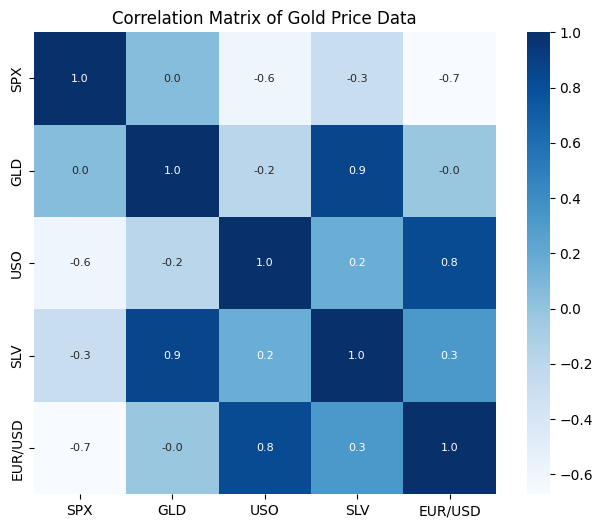

In [30]:
plt.figure(figsize=(8,6))
sns.heatmap(Correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')
plt.title('Correlation Matrix of Gold Price Data')
plt.show()


/tmp/ipykernel_602/1568266501.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Gold['GLD'], color = 'Gold')


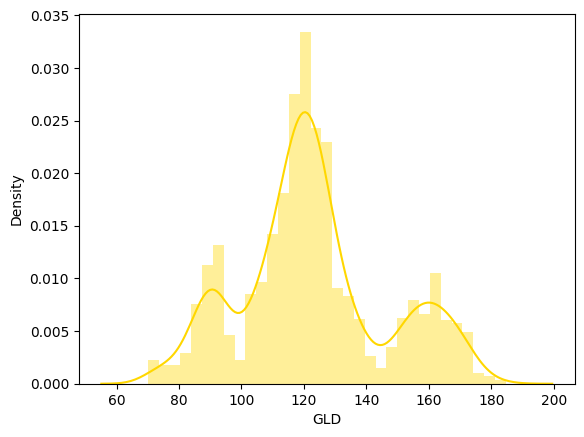

In [31]:
sns.distplot(Gold['GLD'], color = 'Gold')
plt.show()

# Machine learning part

In [32]:
X = Gold2.drop('GLD', axis=1)
Y = Gold2['GLD']

In [33]:
X_train, X_test, Y_train, Y_test,  = train_test_split(X, Y, test_size=0.2, random_state=2)

# Model Training : Random forest Regressor

more than one model


multiple desition tree

In [34]:
Regressor = RandomForestRegressor(n_estimators=100)
Regressor.fit(X_train, Y_train)

RandomForestRegressor()



> Training data



In [35]:
Train_Prediction = Regressor.predict(X_train)

error_score = metrics.r2_score(Y_train, Train_Prediction)
print("R squared error : ", error_score)

R squared error :  0.9983998962481392


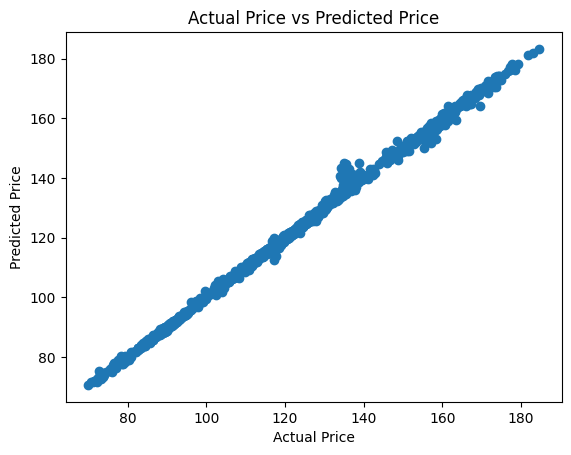

In [36]:
plt.scatter(Y_train, Train_Prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")
plt.show()

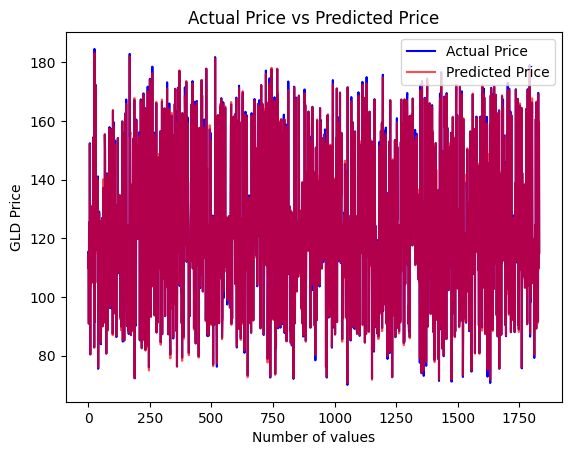

In [51]:
plt.plot(Y_train.reset_index(drop=True), color='blue', label='Actual Price')
plt.plot(Train_Prediction, color='red', label='Predicted Price', alpha=0.7)
plt.title("Actual Price vs Predicted Price")
plt.xlabel('Number of values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()



> test Data



In [37]:
Test_Prediction = Regressor.predict(X_test)

error_score = metrics.r2_score(Y_test, Test_Prediction)
print("R squared error : ", error_score)

R squared error :  0.9891283227294736


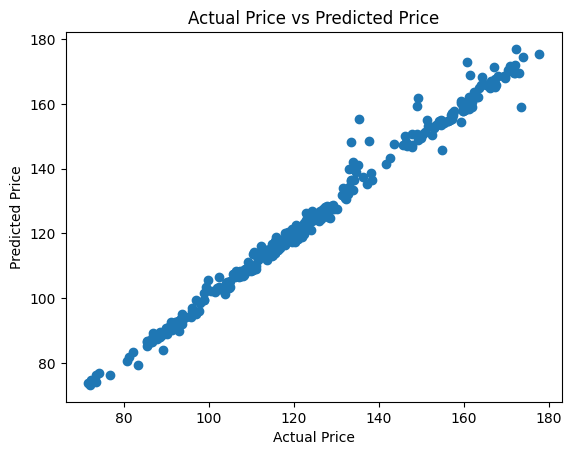

In [38]:
plt.scatter(Y_test, Test_Prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")
plt.show()

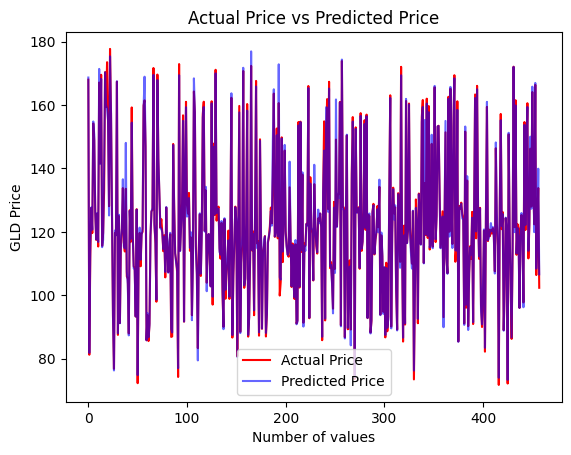

In [56]:
# Drop the old index before plotting
plt.plot(Y_test.reset_index(drop=True), color='red', label='Actual Price')
plt.plot(Test_Prediction, color='blue', label='Predicted Price', alpha=0.6)
plt.title("Actual Price vs Predicted Price")
plt.xlabel('Number of values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()